# 🚀 Spaceship Titanic - Machine Learning Classification

**Kaggle Competition:** Spaceship Titanic

**Objective:**  
Predict whether a passenger was transported to an alternate dimension after the spaceship encountered a spacetime anomaly.

This project follows a complete machine learning workflow including data exploration, preprocessing, feature engineering, model training, and evaluation.

## 📚 Import Libraries

The following libraries are used for:

- Data manipulation: Pandas, NumPy
- Data visualization: Matplotlib, Seaborn
- Machine Learning: Scikit-learn

In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from plottable import Table
from scipy.stats import pearsonr, shapiro, mannwhitneyu, chi2_contingency, fisher_exact

## 📊 Dataset Description

The dataset contains passenger information from the Spaceship Titanic.

### Features:

| Column | Description |
|---|---|
| PassengerId | Unique identifier for each passenger |
| HomePlanet | Planet where the passenger departed from |
| CryoSleep | Indicates whether the passenger was in suspended animation |
| Cabin | Passenger cabin number (deck/number/side) |
| Destination | The planet where the passenger was traveling |
| Age | Passenger age |
| VIP | Whether the passenger had VIP status |
| RoomService | Amount spent on room service |
| FoodCourt | Amount spent at the food court |
| ShoppingMall | Amount spent at the shopping mall |
| Spa | Amount spent at the spa |
| VRDeck | Amount spent on VR activities |
| Name | Passenger name |
| Transported | Target variable: whether the passenger was transported |

In [66]:
df_train = pd.read_csv("../data/train.csv")
df_test = pd.read_csv("../data/test.csv")
df_sample_submission = pd.read_csv("../data/sample_submission.csv")

In [67]:
df_train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [68]:
df_test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [69]:
df_sample_submission.head()

,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,False
3,0021_01,False
4,0023_01,False


In [70]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [71]:
df_train.describe(include = 'all')

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
count,8693,8492,8476,8494,8511,8514.000000,8490,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000,8493,8693
unique,8693,3,2,6560,3,NaN,2,NaN,NaN,NaN,NaN,NaN,8473,2
top,9280_02,Earth,False,G/734/S,TRAPPIST-1e,NaN,False,NaN,NaN,NaN,NaN,NaN,Anton Woody,True
freq,1,4602,5439,8,5915,NaN,8291,NaN,NaN,NaN,NaN,NaN,2,4378
mean,NaN,NaN,NaN,NaN,NaN,28.827930,NaN,224.687617,458.077203,173.729169,311.138778,304.854791,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,14.489021,NaN,666.717663,1611.489240,604.696458,1136.705535,1145.717189,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,19.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,38.000000,NaN,47.000000,76.000000,27.000000,59.000000,46.000000,NaN,NaN


In [72]:
df_train[df_train.duplicated()]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported


In [73]:
df_train = df_train.drop(['PassengerId', 'Name'], axis=1)

In [74]:
df_train.isnull().sum().sort_values(ascending=False)

CryoSleep       217
ShoppingMall    208
VIP             203
HomePlanet      201
Cabin           199
VRDeck          188
Spa             183
FoodCourt       183
Destination     182
RoomService     181
Age             179
Transported       0
dtype: int64

In [75]:
cols = ['VIP', 'CryoSleep', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck','Age','RoomService']

df_train[cols] = df_train[cols].fillna(
    df_train[cols].median()
)

df_train.isnull().sum().sort_values(ascending=False)

HomePlanet      201
Cabin           199
Destination     182
CryoSleep         0
Age               0
VIP               0
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Transported       0
dtype: int64

## EDA

In [76]:
def analysis_numeric_col(data, col):
    fig, axes = plt.subplots(3, 3, figsize=(20, 15))
    colors = ["#9ECAD6", "#ADE792"]

    # ---- without Transported ----
    
    # boxplot
    sns.boxplot(data[col], color="#9ECAD6", ax=axes[0, 0])
    axes[0, 0].set_title(f"Boxplot of {col}")

    # hisplot
    sns.histplot(data[col], kde=True, color="#9ECAD6", ax=axes[0, 1])
    axes[0, 1].set_title(f"Histogram of {col}")

    # qqplot
    stats.probplot(data[col], dist="norm", plot=axes[0, 2])
    line = axes[0, 2].get_lines()[1]
    points = axes[0, 2].get_lines()[0]
    line.set_color("#ADE792")
    points.set_color("#9ECAD6")
    axes[0, 2].set_title(f"QQ-plot of {col}")


    # ---- with Transported ----
    
    # boxplot
    sns.boxplot(x=data["Transported"], y=data[col], color="#9ECAD6", ax=axes[1, 0])
    axes[1, 0].set_title(f"Boxplot of {col} by Transported")

    # hisplot
    sns.histplot(x=data[col], hue=data["Transported"], multiple="stack", palette=["#9ECAD6", "#ADE792"], ax=axes[1, 1])
    axes[1, 1].set_title(f"Histogram of {col} by Transported")

    # qqplot 
    color_map = {0: "#9ECAD6", 1: "#ADE792"}
    groups = sorted(data["Transported"].unique())
    for each in groups:
        res = stats.probplot(data.loc[data["Transported"] == each, col], dist="norm")
        axes[1, 2].plot(res[0][0], res[0][1], "o", color=color_map[each], label=each)
        axes[1, 2].plot(res[0][0], res[1][0]*res[0][0] + res[1][1], color=color_map[each])
        axes[1, 2].set_title(f"QQ-plot of {col} by Transported")
    axes[1, 2].legend(title="Transported", loc="best")

    # kdeplot
    sns.kdeplot(data, x=col, hue="Transported", fill=True, common_norm=False, palette=["#9ECAD6", "#ADE792"], ax=axes[2, 0])
    axes[2, 0].set_title(f"KDE of {col} by Transported")

    # # stacked bar 
    # cross_tab = pd.crosstab(data[col], data["Transported"])
    # cross_tab = cross_tab.div(cross_tab.sum(axis=1), axis=0)
    # cross_tab.plot(kind="bar", stacked=True, ax=axes[2, 1], color=colors)
    # axes[2, 1].set_ylim(0, 1)
    # axes[2, 1].set_title(f"Stacked Bar of {col} by Transported")

    axes[2, 2].remove()
    
    # stacked bar 2   
    if isinstance(data[col][0], float):
        binned = pd.cut(data[col], bins=8)
        ctab = pd.crosstab(binned, data['Transported'])
        ctab = ctab.div(ctab.sum(axis=1), axis=0)
        ctab.plot(kind="bar", stacked=True, ax=axes[2, 1], width=1.0, color=colors, edgecolor='black', legend=True)
        axes[2, 1].set_ylim(0, 1)
        axes[2, 1].set_title(f"Stacked Bar of {col} by Transported")
        axes[2, 1].tick_params(axis='x', rotation=0)
        new_labels = [f"{interval.left:.2f}" for interval in ctab.index]
        axes[2, 1].set_xticklabels(new_labels)
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
    else:
        binned = pd.cut(data[col], bins=8)
        ctab = pd.crosstab(binned, data['Transported'])
        ctab = ctab.div(ctab.sum(axis=1), axis=0)
        ctab.plot(kind="bar", stacked=True, ax=axes[2, 1], width=1.0, color=colors, edgecolor='black', legend=True)
        axes[2, 1].set_ylim(0, 1)
        axes[2, 1].set_title(f"Stacked Bar of {col} by Transported")
        axes[2, 1].tick_params(axis='x', rotation=0)
        new_labels = [f"{int(interval.left)}" for interval in ctab.index]
        axes[2, 1].set_xticklabels(new_labels)
        plt.xticks(rotation=90)
        
    plt.tight_layout()
    plt.show()

In [77]:
def mannwhitney_test(data, col):
    group0 = data[data['Transported'] == 0][col]
    group1 = data[data['Transported'] == 1][col]
    print(group0.shape)
    print(group1.shape)

    print(group0.head())
    print(group1.head())

    stat, p_value = mannwhitneyu(group0, group1, alternative='two-sided')

    print(f"\n{col} → p_value = {p_value:.4f}")

    # Interpretation
    if p_value > 0.05:
        print("✅ No significant difference → Fail to reject H₀")
    else:
        print("❌ Significant difference → Reject H₀")

C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1075: FutureWarn

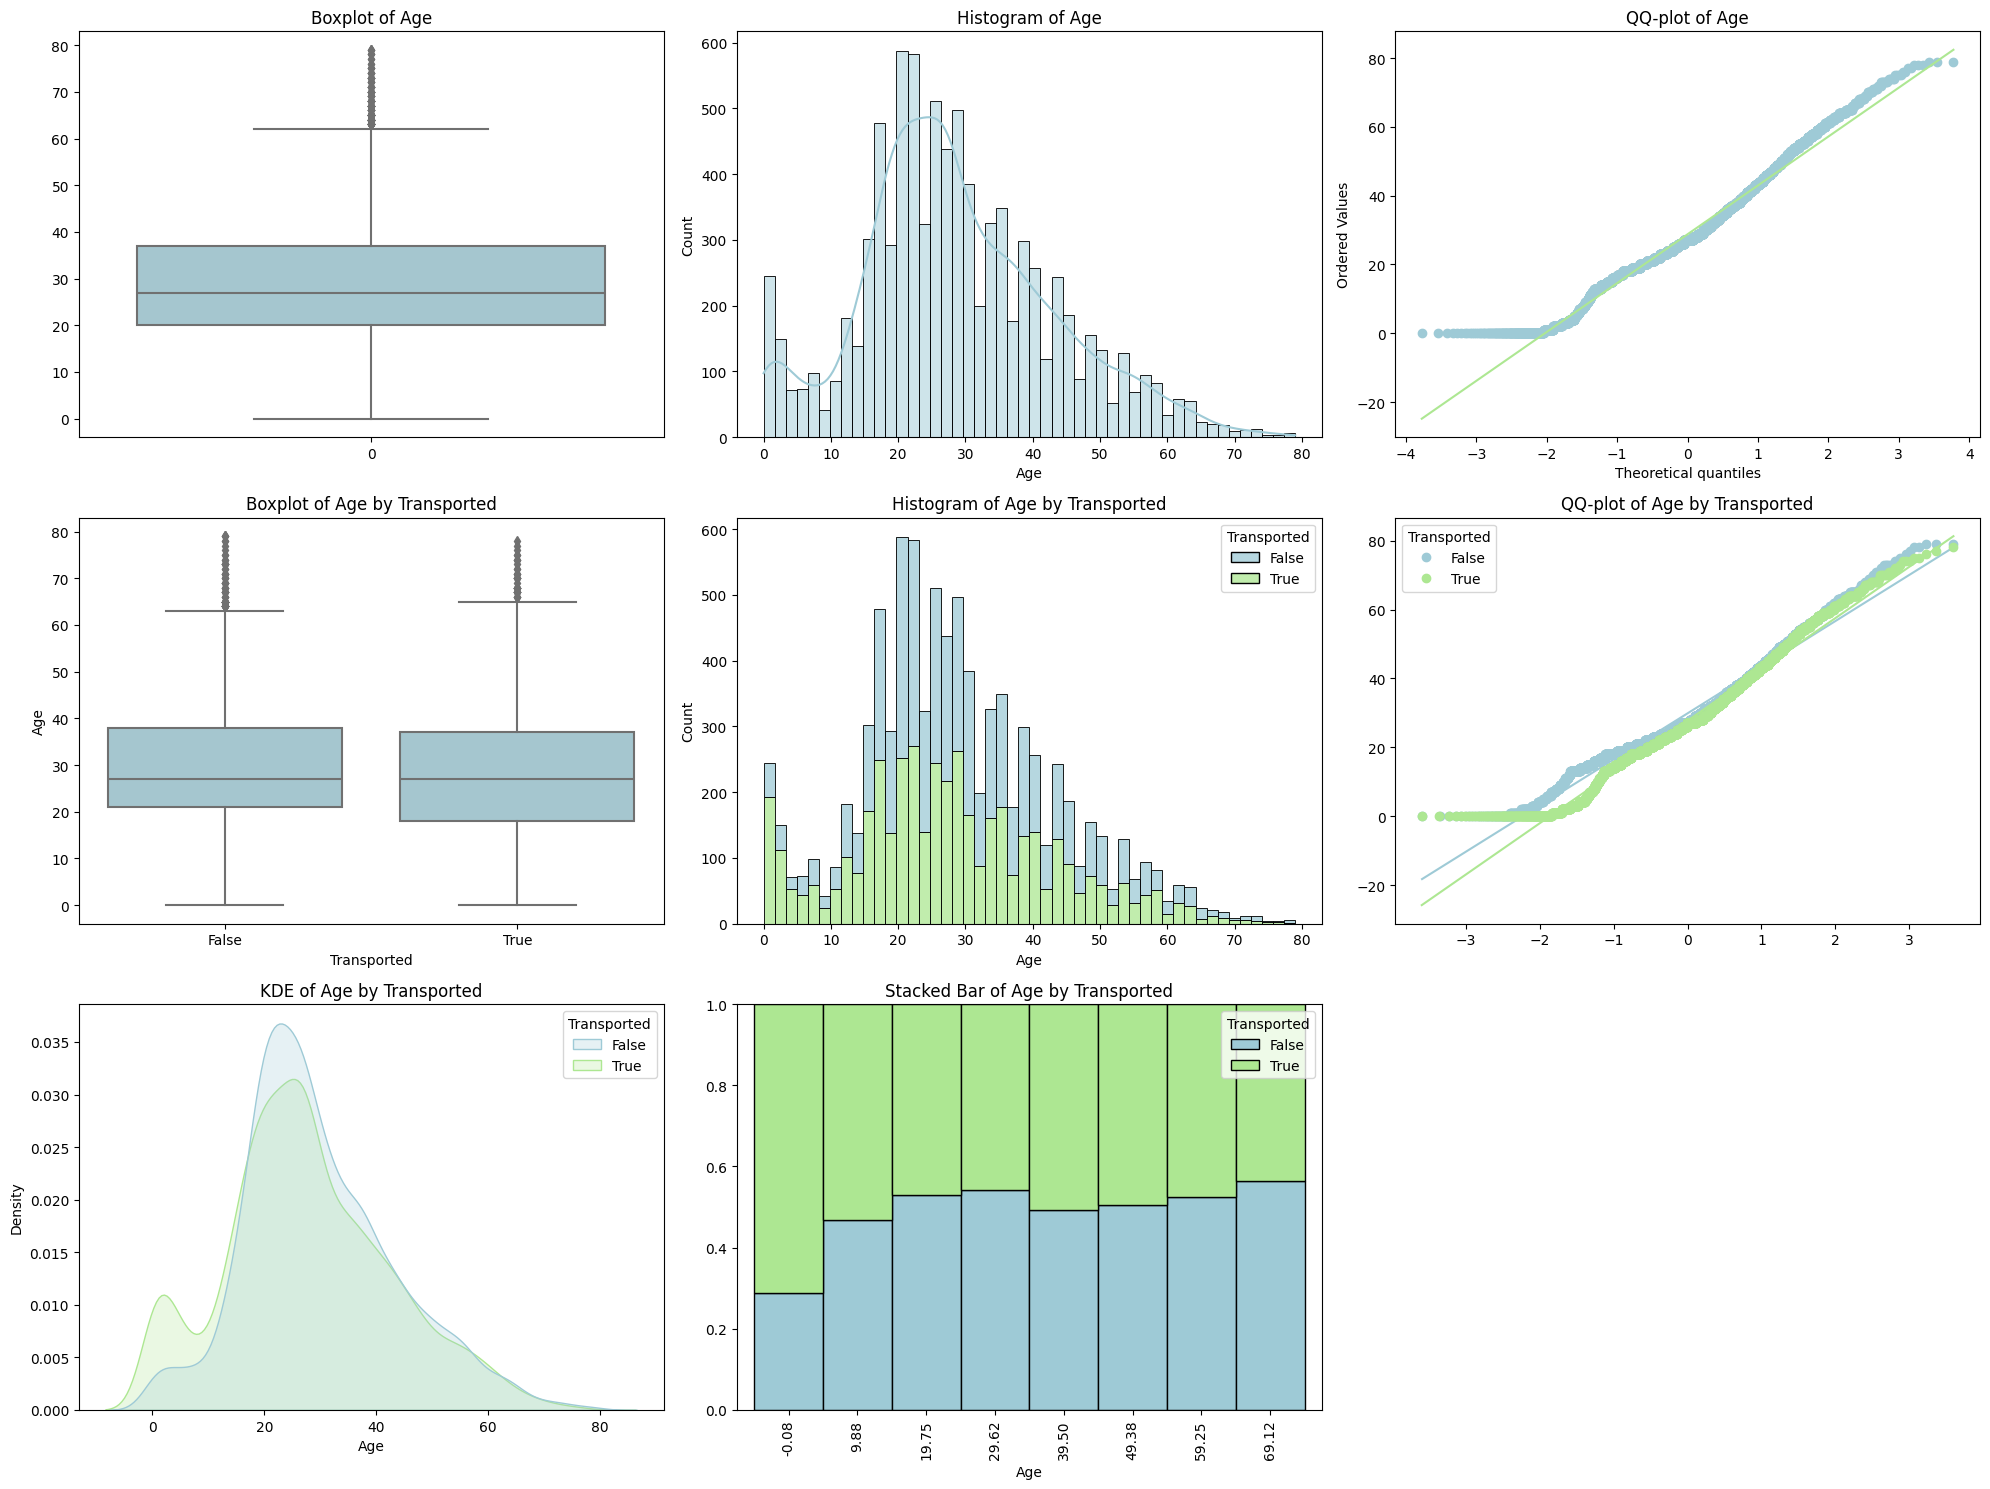

<Figure size 640x480 with 0 Axes>

(4315,)
(4378,)
0     39.0
2     58.0
3     33.0
13    48.0
15    31.0
Name: Age, dtype: float64
1    24.0
4    16.0
5    44.0
6    26.0
7    28.0
Name: Age, dtype: float64

Age → p_value = 0.0000
❌ Significant difference → Reject H₀


In [78]:
analysis_numeric_col(df_train,"Age")
mannwhitney_test(df_train,"Age")

C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1075: FutureWarn

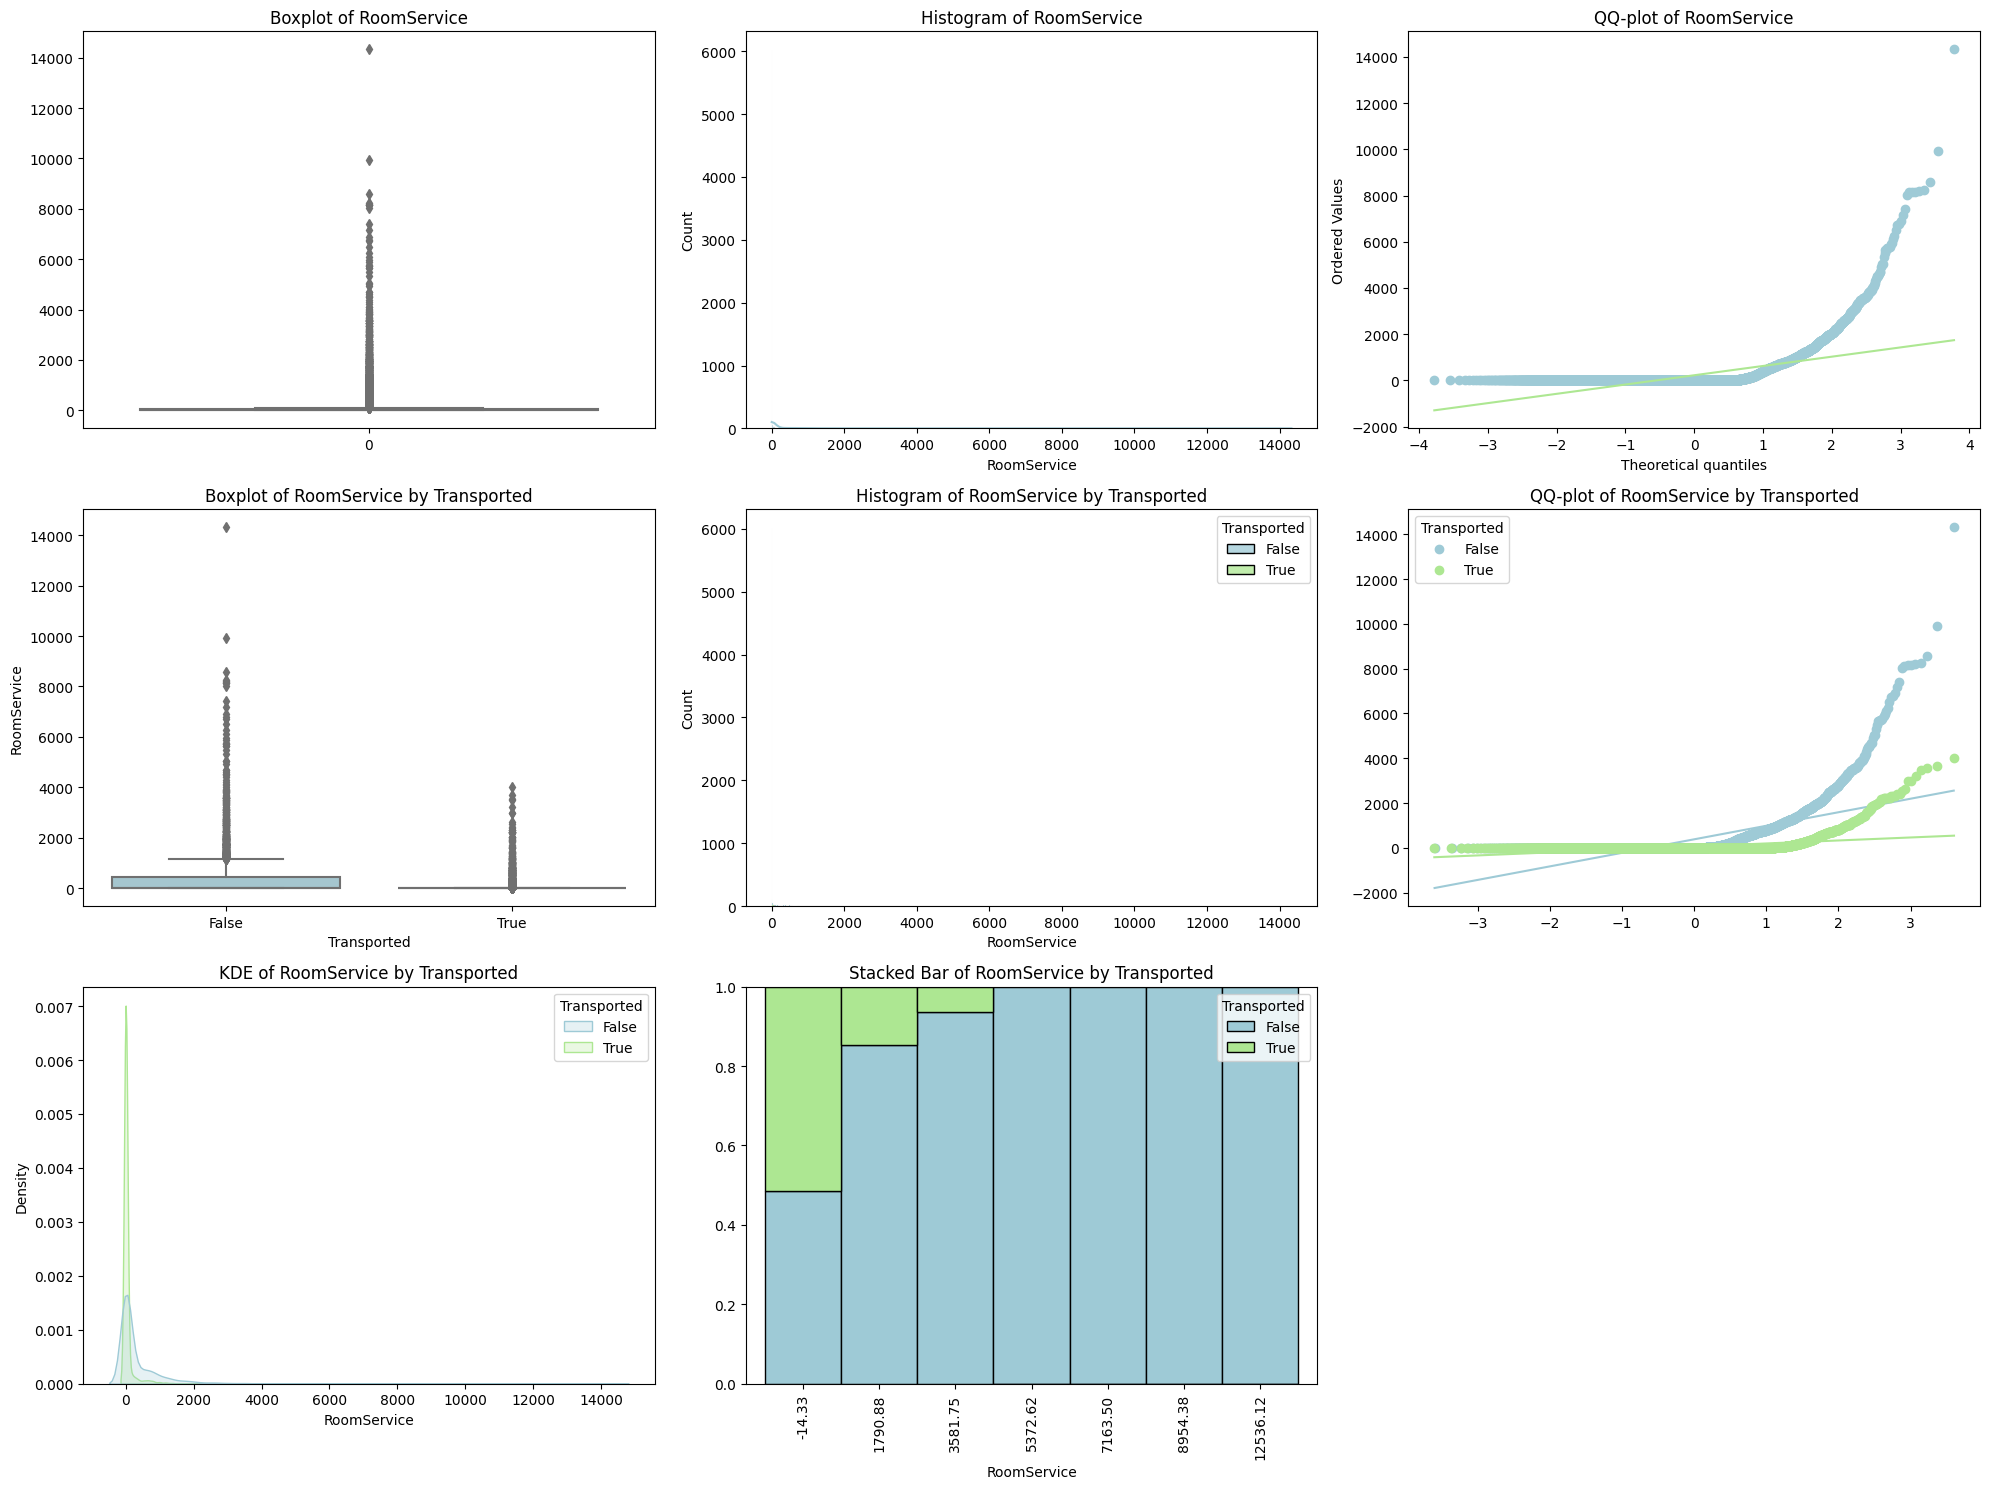

<Figure size 640x480 with 0 Axes>

(4315,)
(4378,)
0       0.0
2      43.0
3       0.0
13    719.0
15     32.0
Name: RoomService, dtype: float64
1    109.0
4    303.0
5      0.0
6     42.0
7      0.0
Name: RoomService, dtype: float64

RoomService → p_value = 0.0000
❌ Significant difference → Reject H₀


In [79]:
analysis_numeric_col(df_train,"RoomService")
mannwhitney_test(df_train,"RoomService")


C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1075: FutureWarn

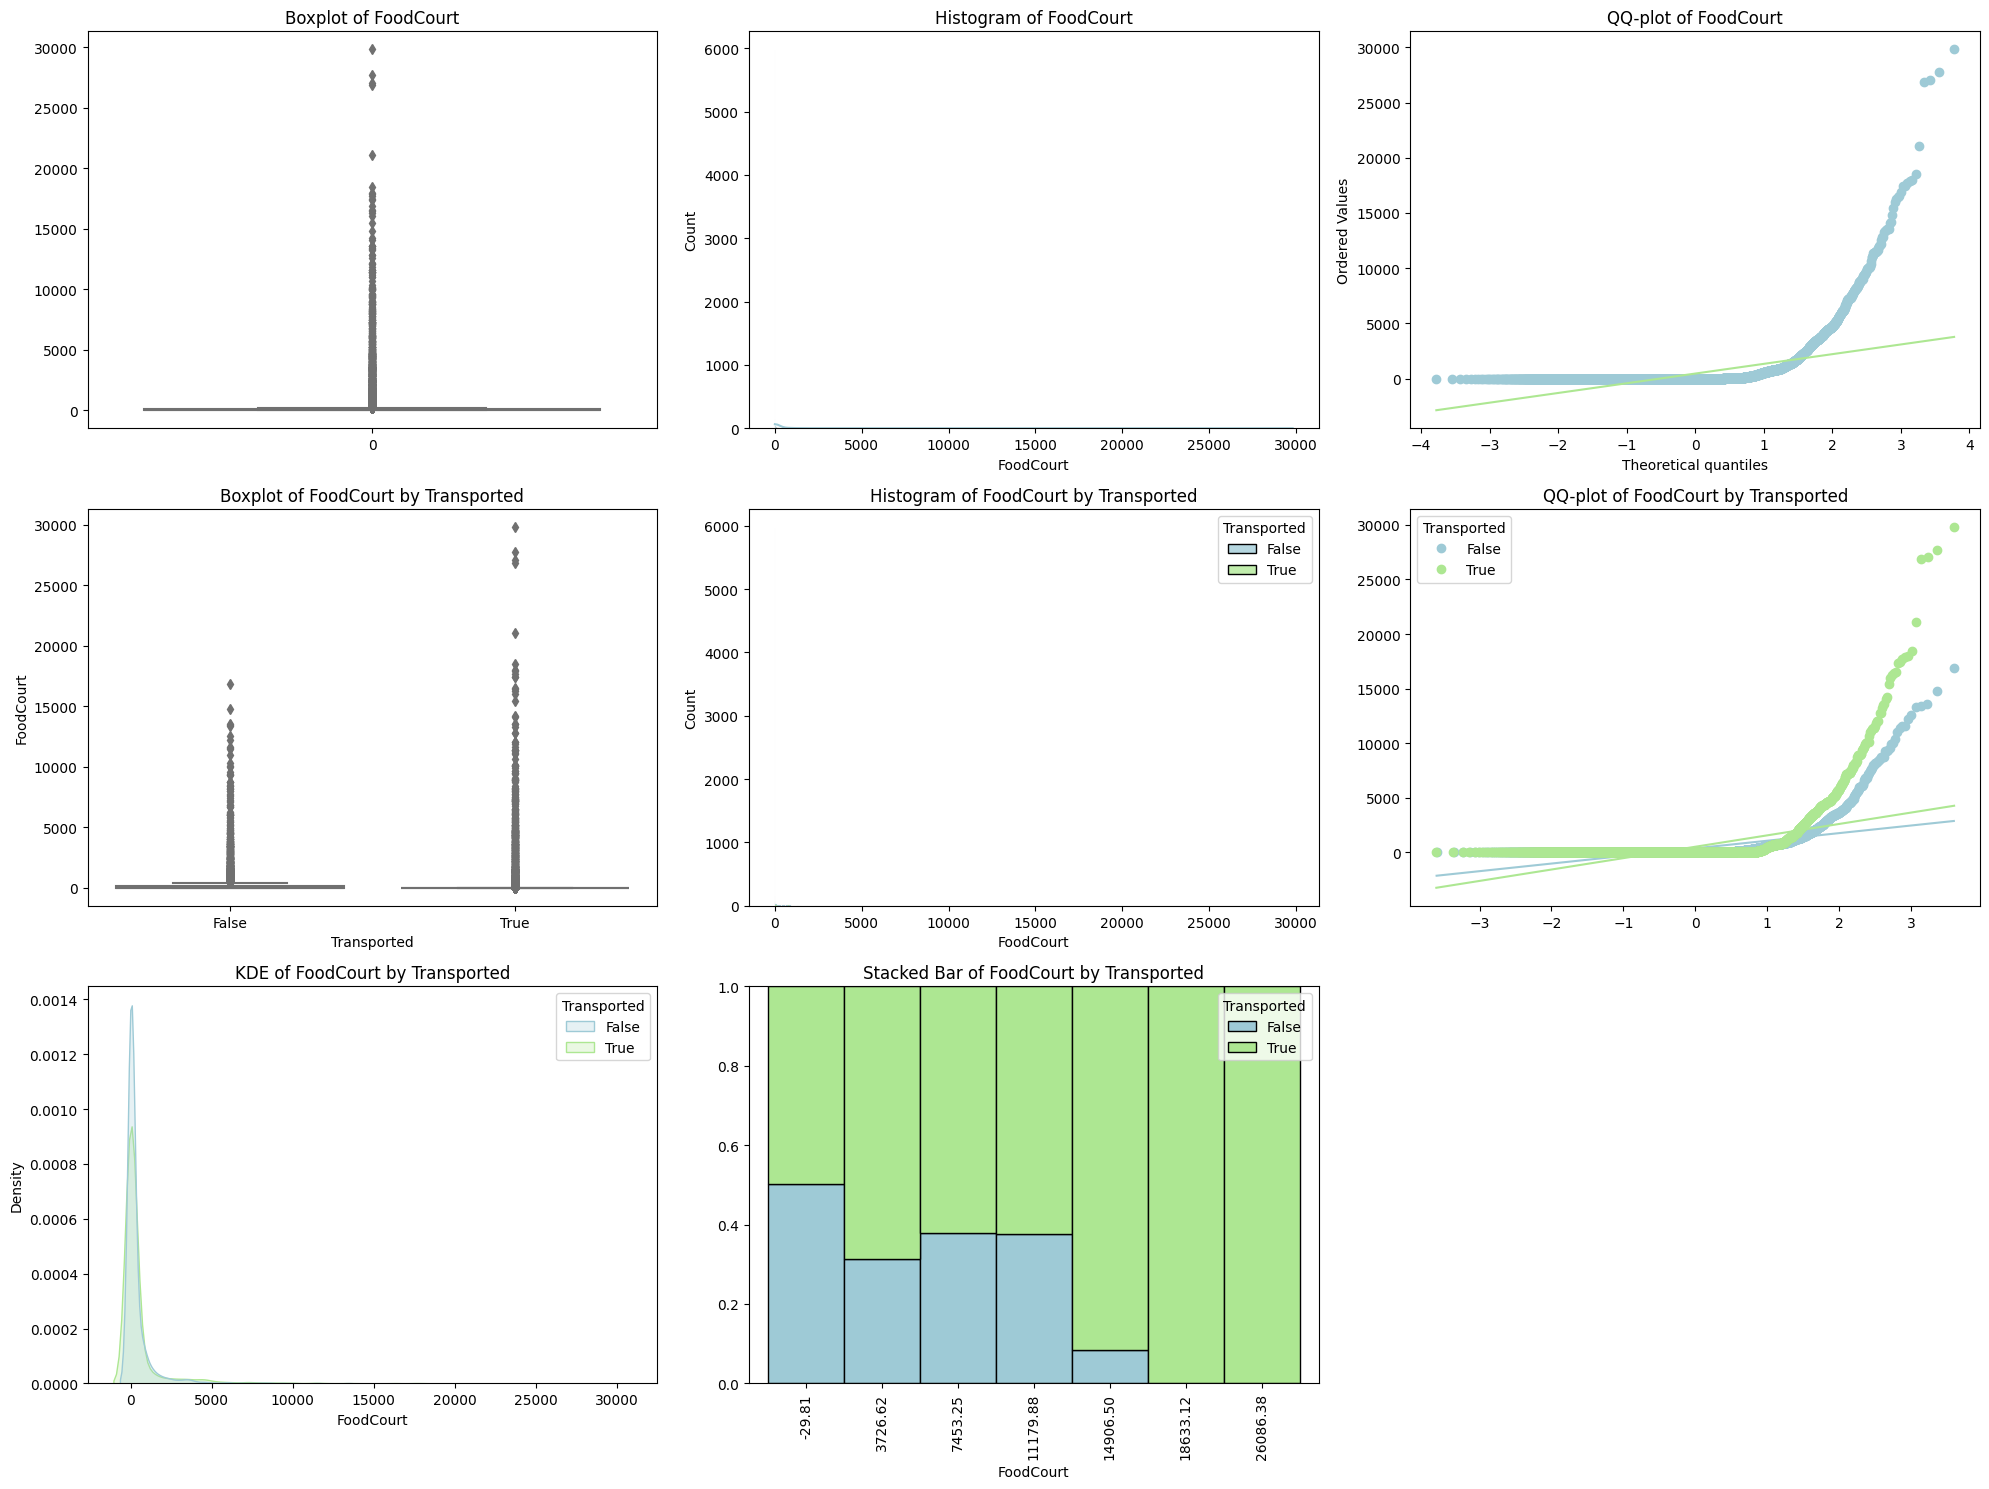

<Figure size 640x480 with 0 Axes>

(4315,)
(4378,)
0        0.0
2     3576.0
3     1283.0
13       1.0
15       0.0
Name: FoodCourt, dtype: float64
1       9.0
4      70.0
5     483.0
6    1539.0
7       0.0
Name: FoodCourt, dtype: float64

FoodCourt → p_value = 0.0000
❌ Significant difference → Reject H₀


In [80]:
analysis_numeric_col(df_train,"FoodCourt")
mannwhitney_test(df_train,"FoodCourt")

C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1075: FutureWarn

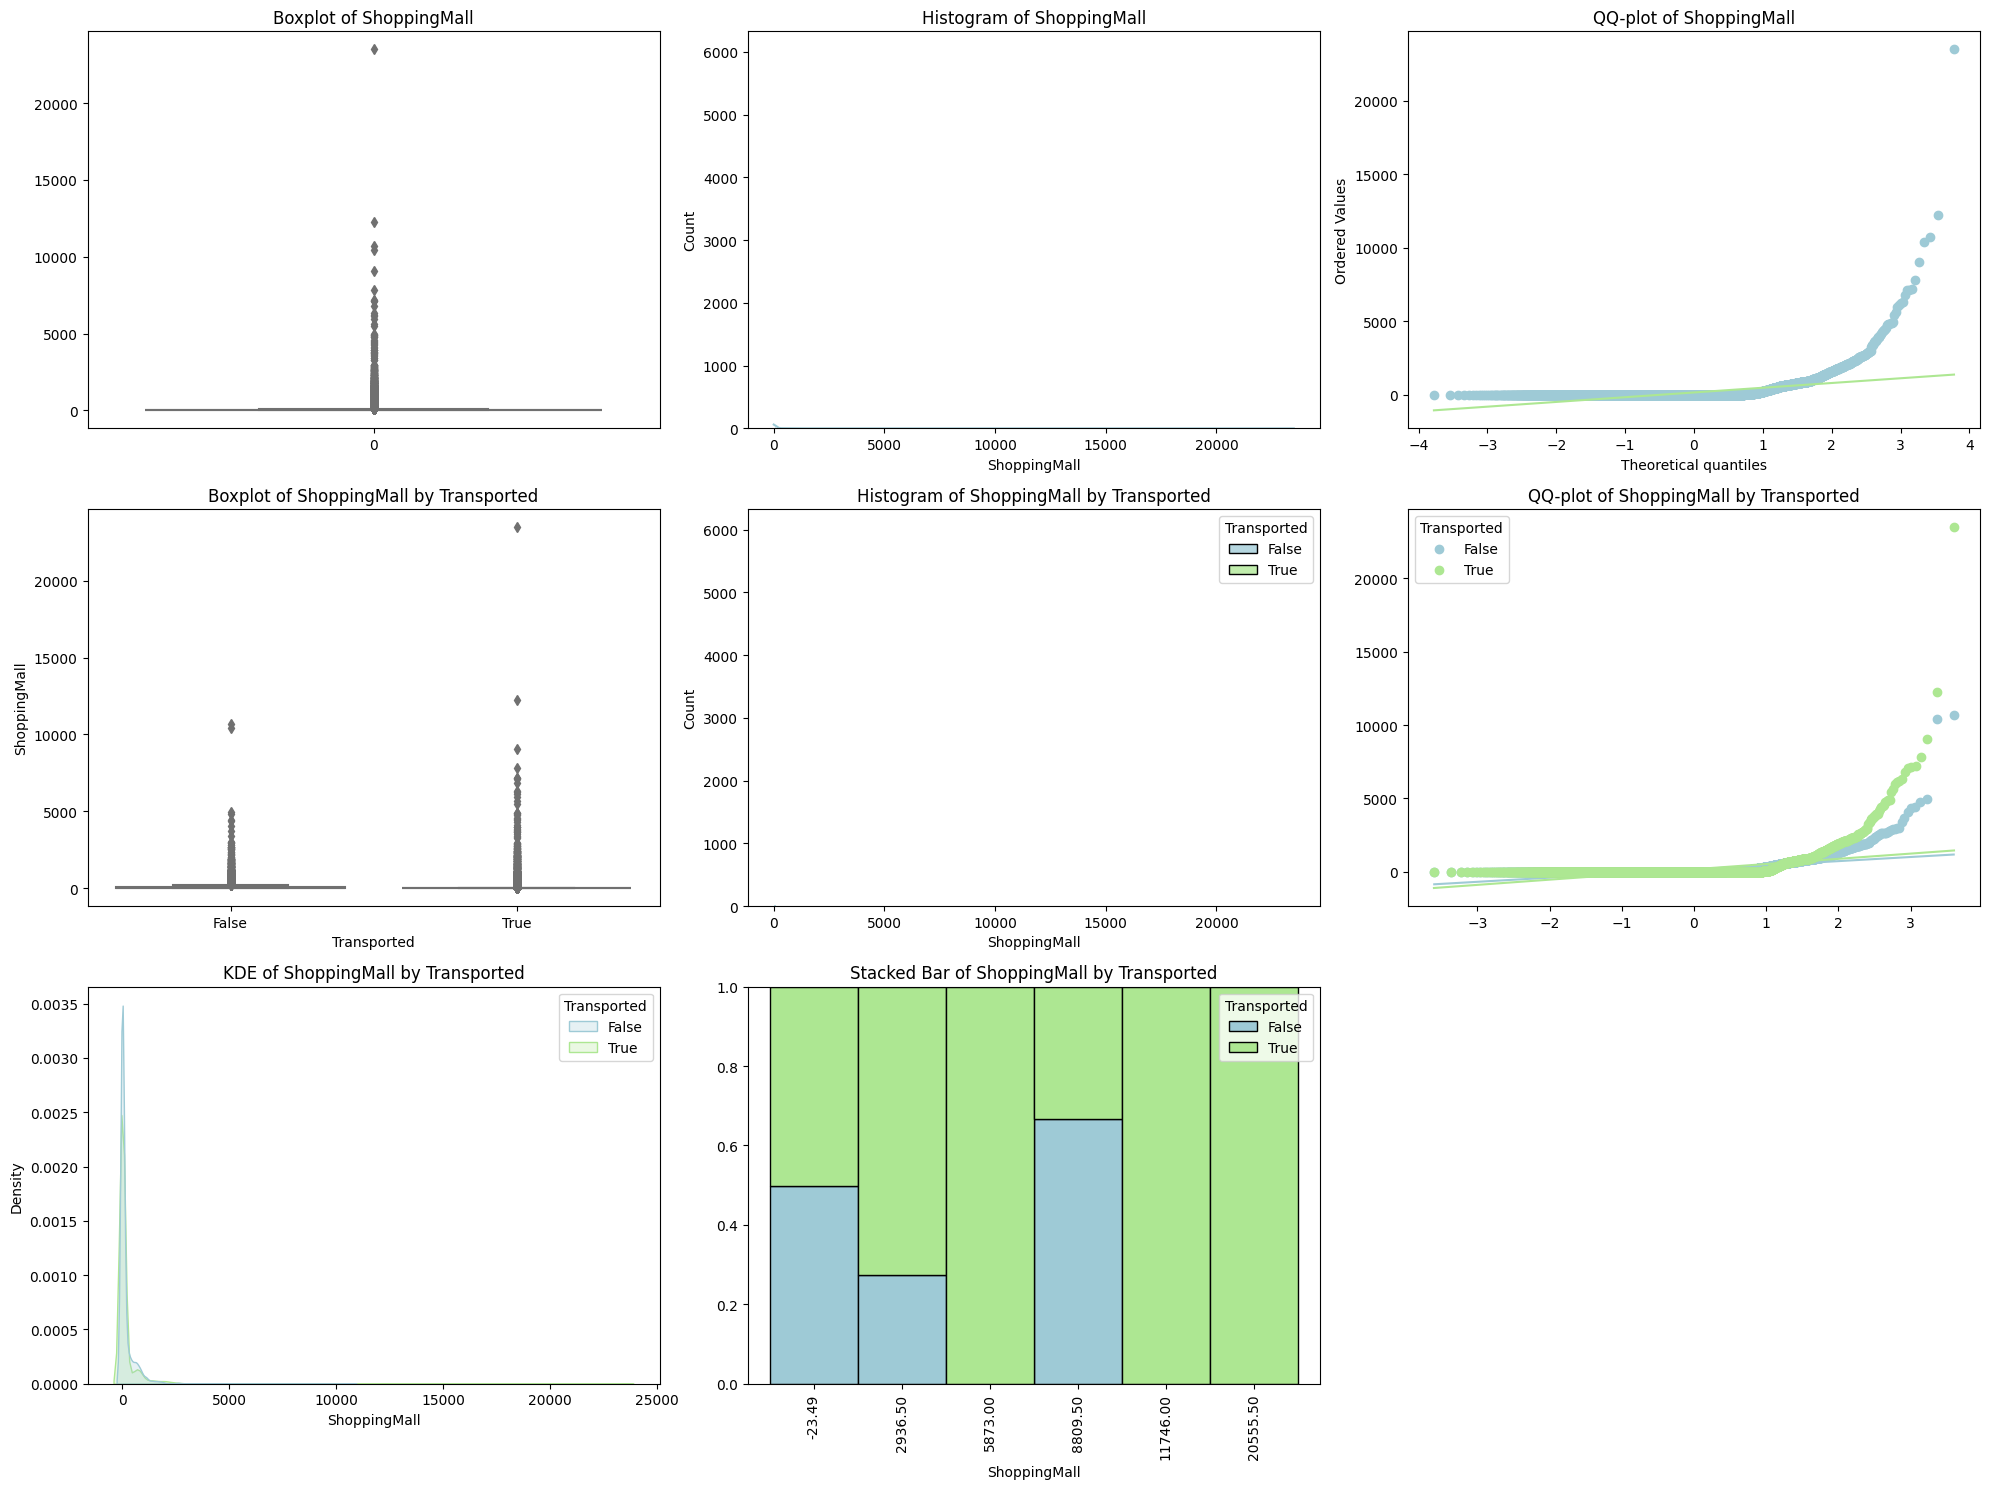

<Figure size 640x480 with 0 Axes>

(4315,)
(4378,)
0       0.0
2       0.0
3     371.0
13     65.0
15    876.0
Name: ShoppingMall, dtype: float64
1     25.0
4    151.0
5      0.0
6      3.0
7      0.0
Name: ShoppingMall, dtype: float64

ShoppingMall → p_value = 0.0000
❌ Significant difference → Reject H₀


In [81]:
analysis_numeric_col(df_train,"ShoppingMall")
mannwhitney_test(df_train,"ShoppingMall")

C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1075: FutureWarn

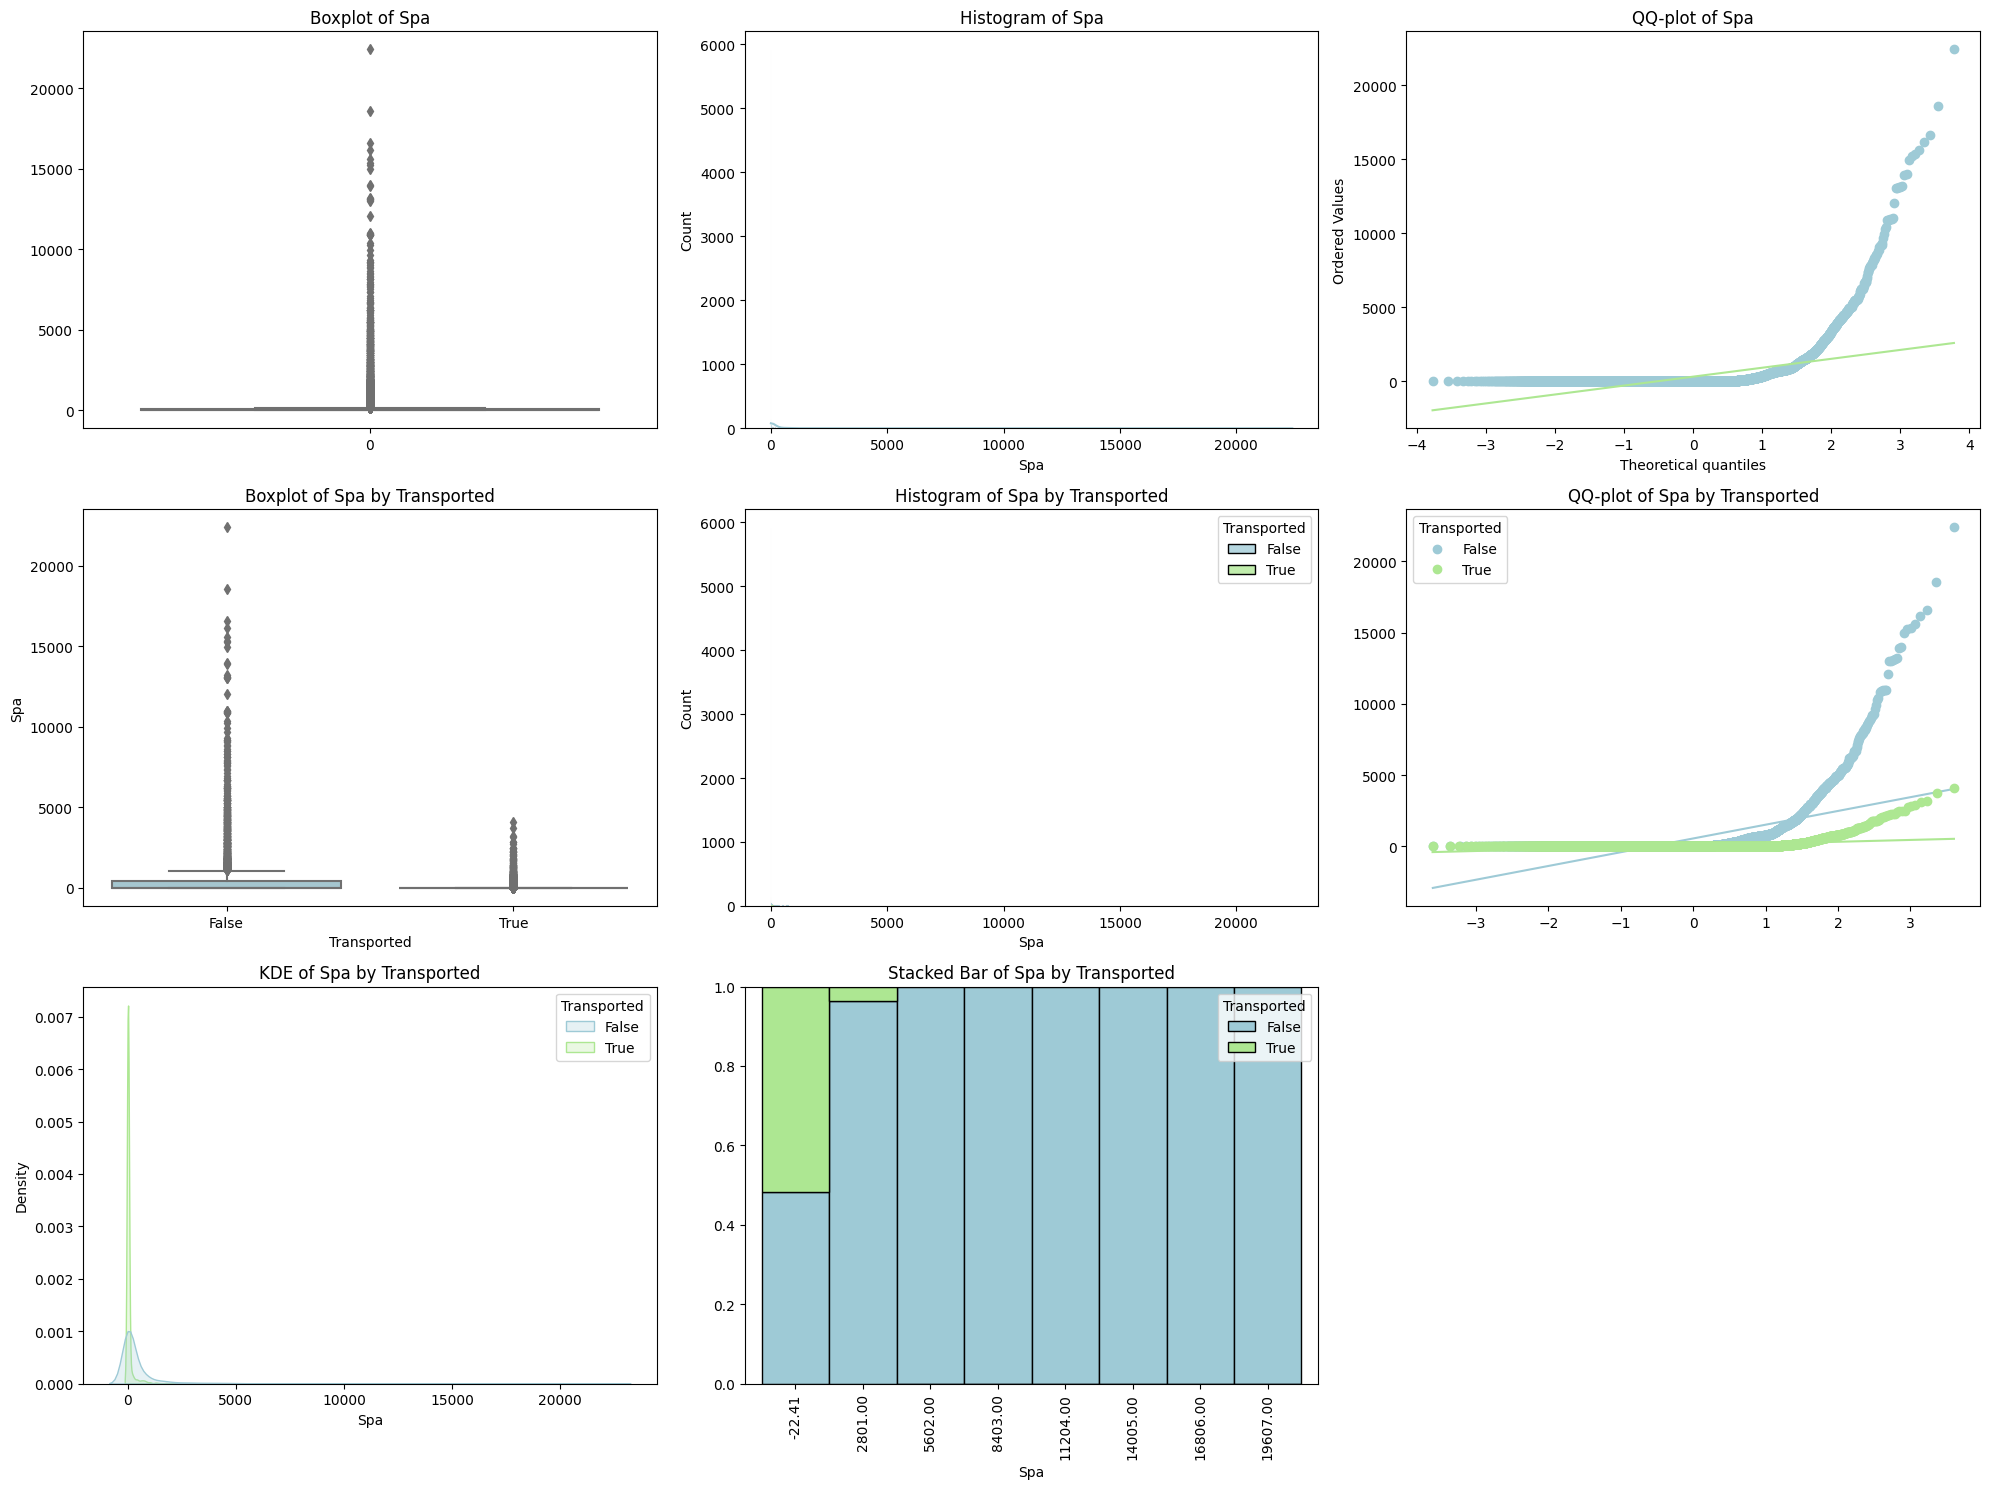

<Figure size 640x480 with 0 Axes>

(4315,)
(4378,)
0        0.0
2     6715.0
3     3329.0
13       0.0
15       0.0
Name: Spa, dtype: float64
1    549.0
4    565.0
5    291.0
6      0.0
7      0.0
Name: Spa, dtype: float64

Spa → p_value = 0.0000
❌ Significant difference → Reject H₀


In [82]:
analysis_numeric_col(df_train,"Spa")
mannwhitney_test(df_train,"Spa")

C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1075: FutureWarn

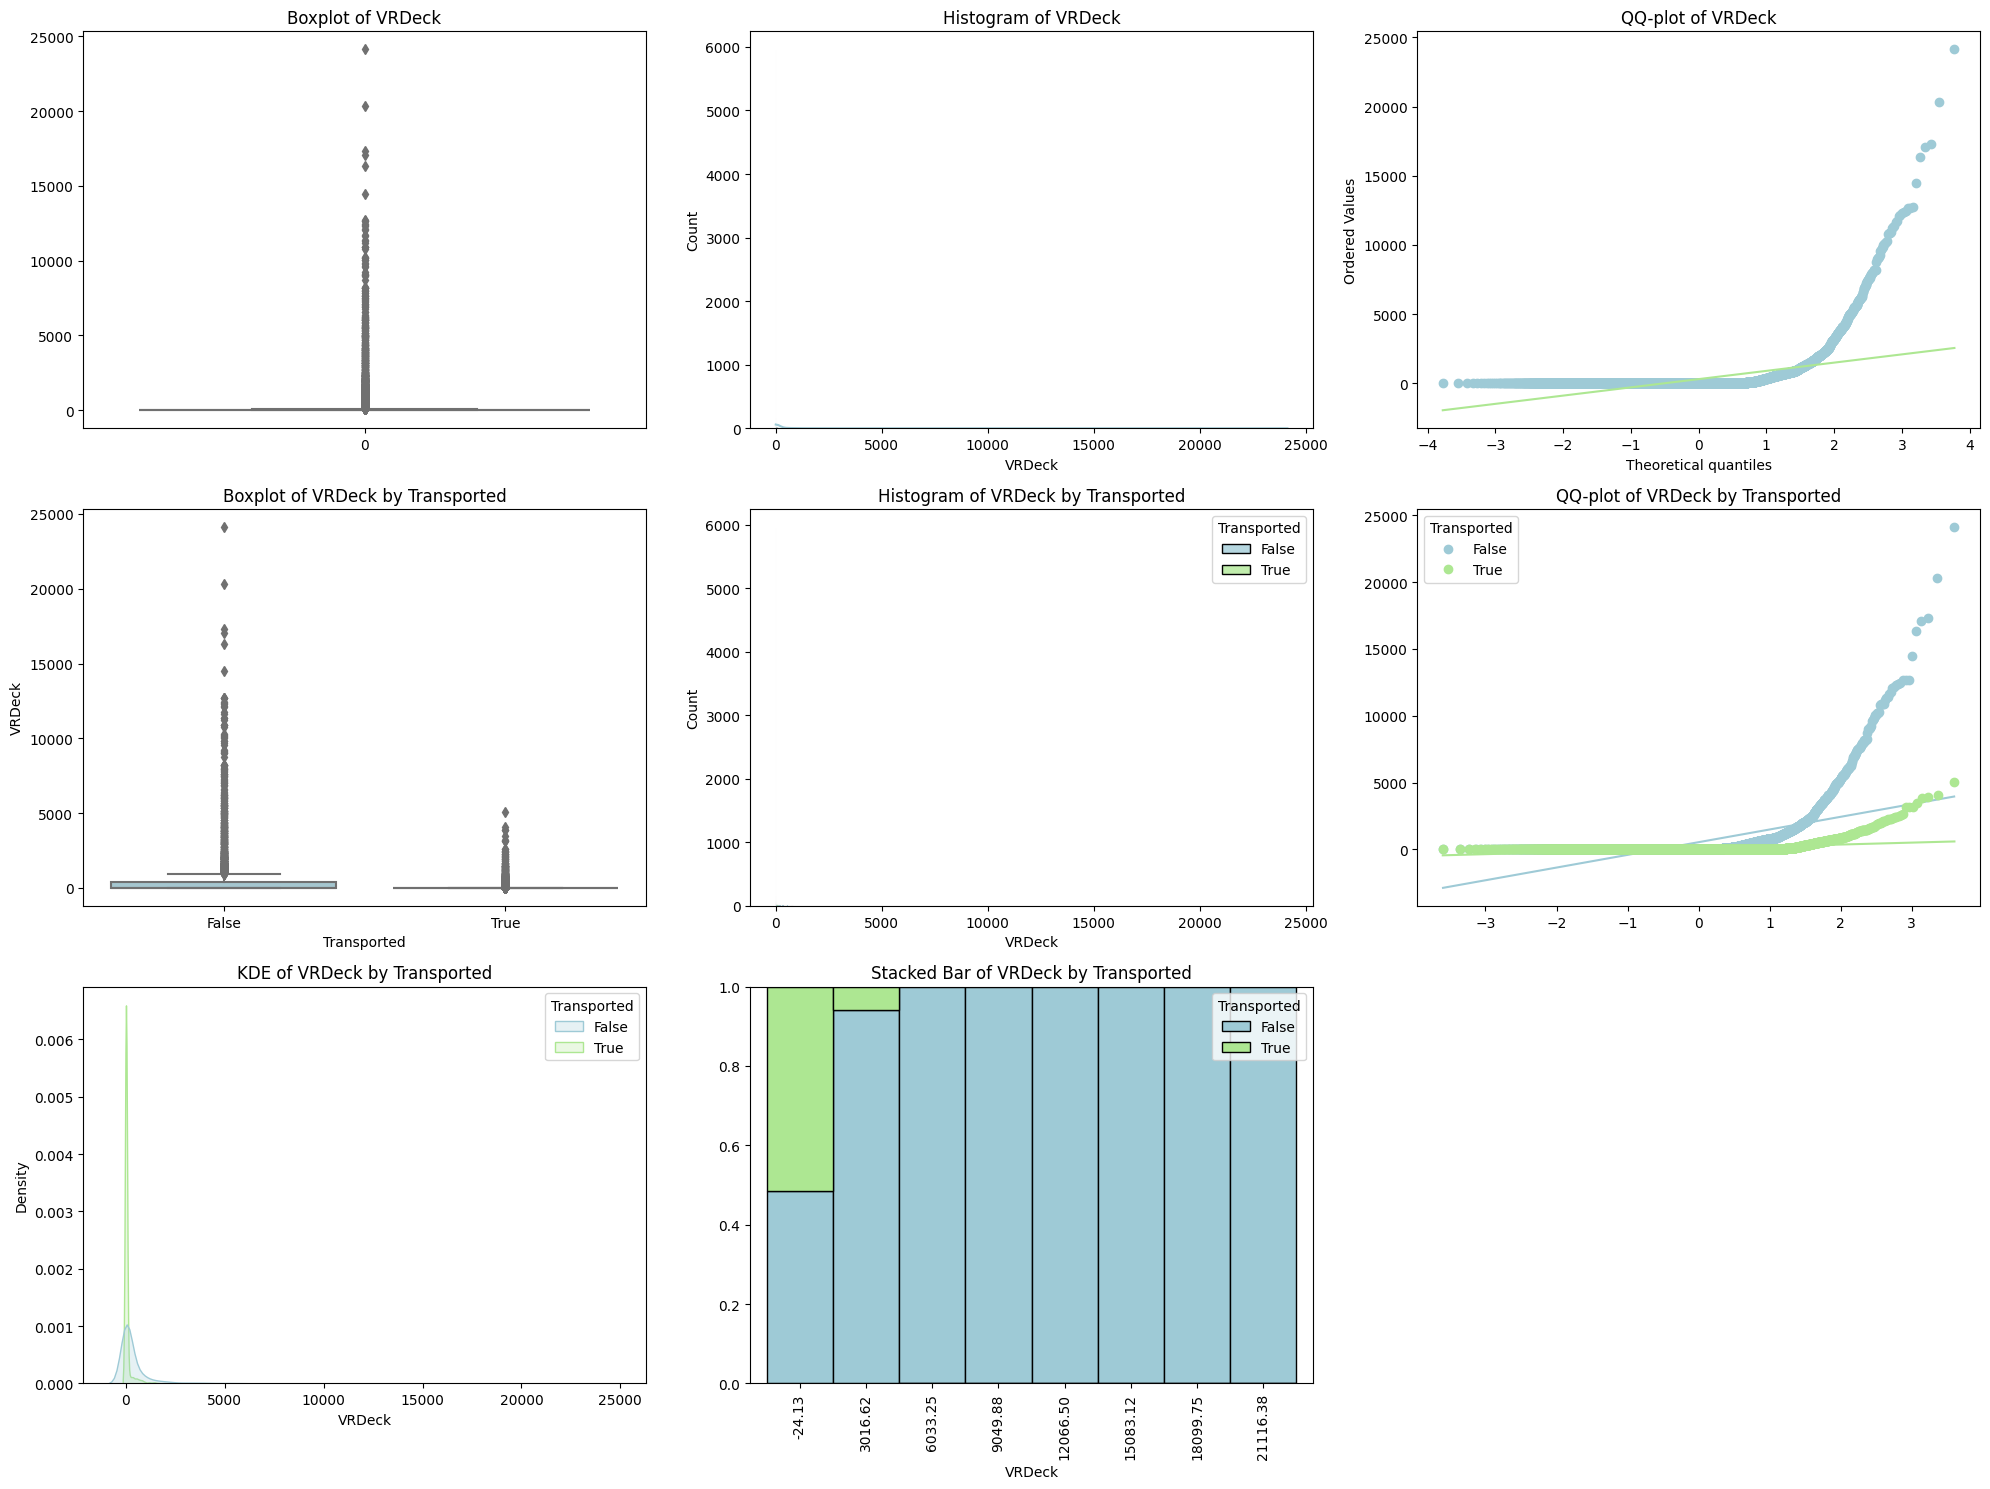

<Figure size 640x480 with 0 Axes>

(4315,)
(4378,)
0       0.0
2      49.0
3     193.0
13     24.0
15      0.0
Name: VRDeck, dtype: float64
1    44.0
4     2.0
5     0.0
6     0.0
7     0.0
Name: VRDeck, dtype: float64

VRDeck → p_value = 0.0000
❌ Significant difference → Reject H₀


In [83]:
analysis_numeric_col(df_train,"VRDeck")
mannwhitney_test(df_train,"VRDeck")